# Suvendu Bista  
**Course:** Advanced Big Data and Data Mining (MSCS-634-B01)  
**📊 Project Deliverable 3: Classification, Clustering, and Pattern Mining**


In [ ]:
 # Preparing Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import GridSearchCV

# Reload the cleaned dataset
df = pd.read_csv('csv/cleaned_world_bank_data_2025.csv')

# Verify data loaded successfully
print("Data loaded successfully. Shape:", df.shape)
print(df.head())

Data loaded successfully. Shape: (3472, 16)
  country_name country_id    year  Inflation (CPI %)  GDP (Current USD)  \
0        Aruba         aw  2010.0           2.078141       2.453597e+09   
1        Aruba         aw  2011.0           4.316297       2.637859e+09   
2        Aruba         aw  2012.0           0.627472       2.615208e+09   
3        Aruba         aw  2013.0          -1.573317       2.727850e+09   
4        Aruba         aw  2014.0           0.421441       2.790850e+09   

   GDP per Capita (Current USD)  Unemployment Rate (%)  \
0                  24093.140151                  5.771   
1                  25712.384302                  5.771   
2                  25119.665545                  5.771   
3                  25813.576727                  5.771   
4                  26129.839062                  5.771   

   Interest Rate (Real, %)  Inflation (GDP Deflator, %)  \
0                11.666131                    -1.223407   
1                 4.801974            

In [31]:
# Classification Models
# Preparing classification target

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature Engineering

# Binary target: High GDP per capita
median_gdp = df['GDP per Capita (Current USD)'].median()
df['High_GDP'] = (df['GDP per Capita (Current USD)'] > median_gdp).astype(int)

# Creating engineered features if they don't already exist
if 'GDP_per_Capita_Growth' not in df.columns:
    df['GDP_per_Capita_Growth'] = df['GDP per Capita (Current USD)'].pct_change().fillna(0)

if 'Inflation_Diff' not in df.columns:
    df['Inflation_Diff'] = df['Inflation (CPI %)'].diff().fillna(0)

if 'Govt_Efficiency' not in df.columns:
    # Avoid division by zero
    df['Govt_Efficiency'] = df['Government Expense (% of GDP)'] / (df['Tax Revenue (% of GDP)'] + 1e-6)

if 'Economic_Health' not in df.columns:
    df['Economic_Health'] = df['GDP Growth (% Annual)'] - df['Unemployment Rate (%)']


# Feature Selection

features = [
    'year', 'Inflation (CPI %)', 'Unemployment Rate (%)', 
    'Interest Rate (Real, %)', 'GDP Growth (% Annual)',
    'Current Account Balance (% GDP)', 'Government Expense (% of GDP)',
    'Tax Revenue (% of GDP)', 'Public Debt (% of GDP)',
    'GDP_per_Capita_Growth', 'Inflation_Diff', 'Govt_Efficiency',
    'Economic_Health'
]

# Only keeping features that exist in df
available_features = [f for f in features if f in df.columns]
X = df[available_features]
y = df['High_GDP']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Summary

print("\nClassification data prepared:")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Features used: {available_features}")
print(f"Percentage of high GDP countries: {y.mean():.2%}")



Classification data prepared:
Training samples: 2430, Test samples: 1042
Features used: ['year', 'Inflation (CPI %)', 'Unemployment Rate (%)', 'Interest Rate (Real, %)', 'GDP Growth (% Annual)', 'Current Account Balance (% GDP)', 'Government Expense (% of GDP)', 'Tax Revenue (% of GDP)', 'Public Debt (% of GDP)', 'GDP_per_Capita_Growth', 'Inflation_Diff', 'Govt_Efficiency', 'Economic_Health']
Percentage of high GDP countries: 42.31%



Random Forest Classifier Performance:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       601
           1       0.87      0.84      0.85       441

    accuracy                           0.88      1042
   macro avg       0.88      0.87      0.88      1042
weighted avg       0.88      0.88      0.88      1042



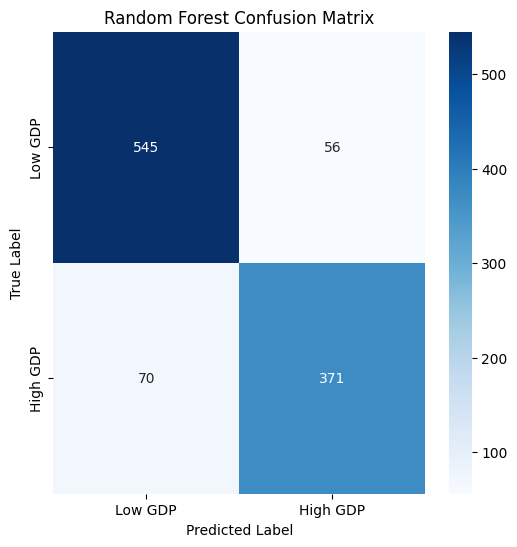

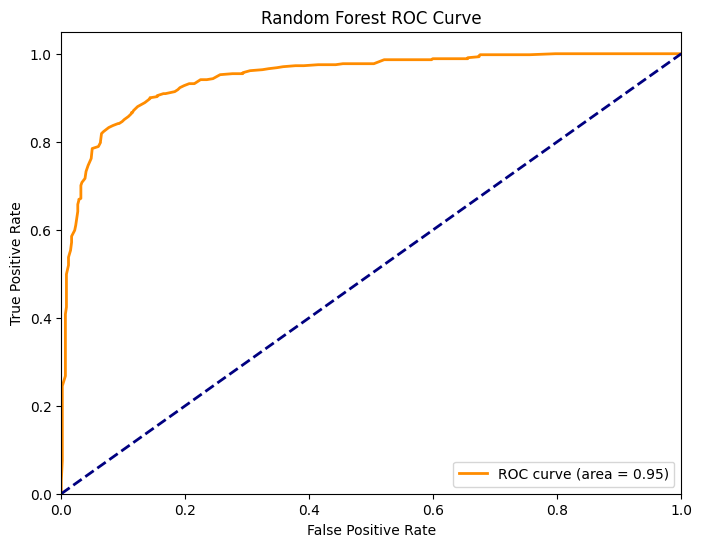

In [34]:
# Random Forest Classifier

# Initializing and train Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

# Making predictions
y_pred_rf = rf_clf.predict(X_test_scaled)
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluating performance
print("\nRandom Forest Classifier Performance:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low GDP', 'High GDP'], 
            yticklabels=['Low GDP', 'High GDP'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()


SVM Classifier Performance:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       601
           1       0.84      0.77      0.80       441

    accuracy                           0.84      1042
   macro avg       0.84      0.83      0.84      1042
weighted avg       0.84      0.84      0.84      1042



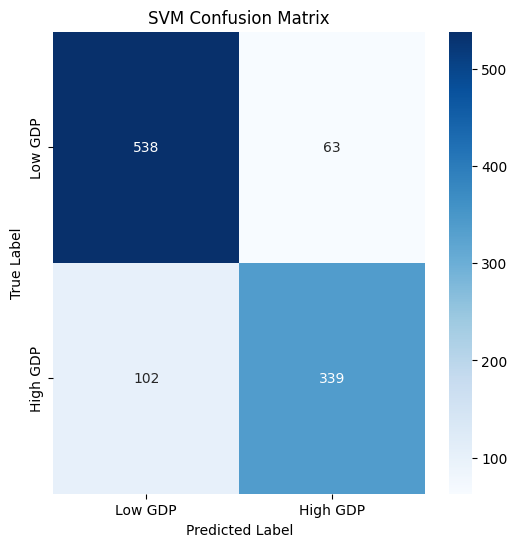

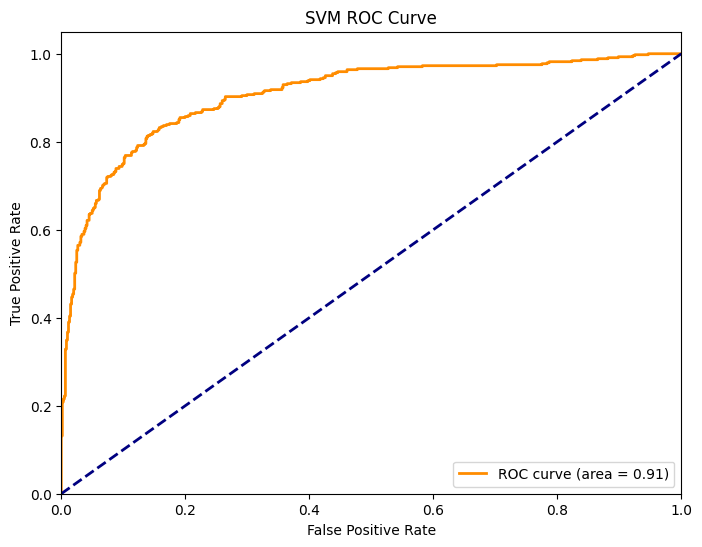

In [35]:
# Support Vector Machine Machine Classifier

# Initializing and train SVM classifier
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# Making predictions
y_pred_svm = svm_clf.predict(X_test_scaled)
y_prob_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluateing performance
print("\nSVM Classifier Performance:")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low GDP', 'High GDP'], 
            yticklabels=['Low GDP', 'High GDP'])
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc="lower right")
plt.show()

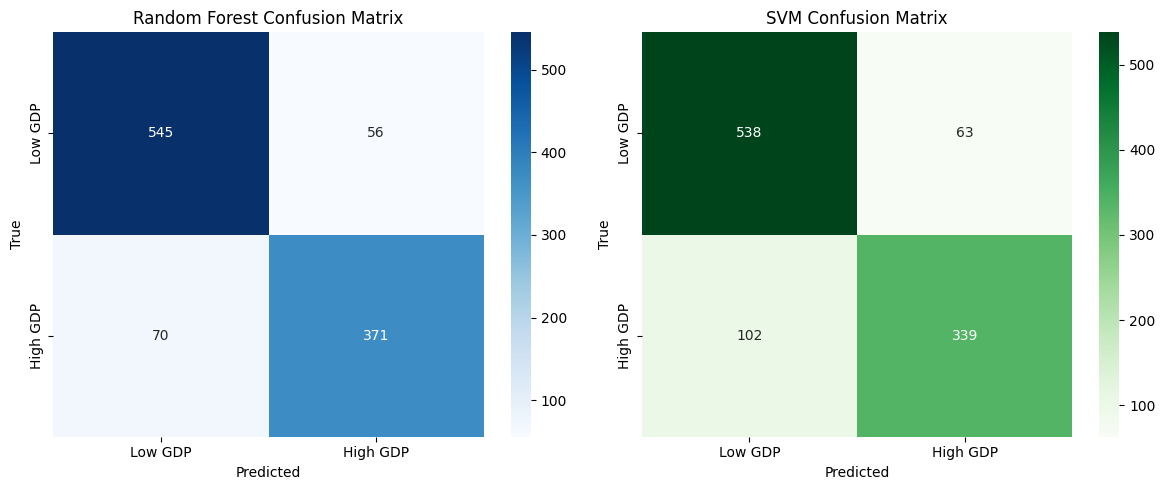

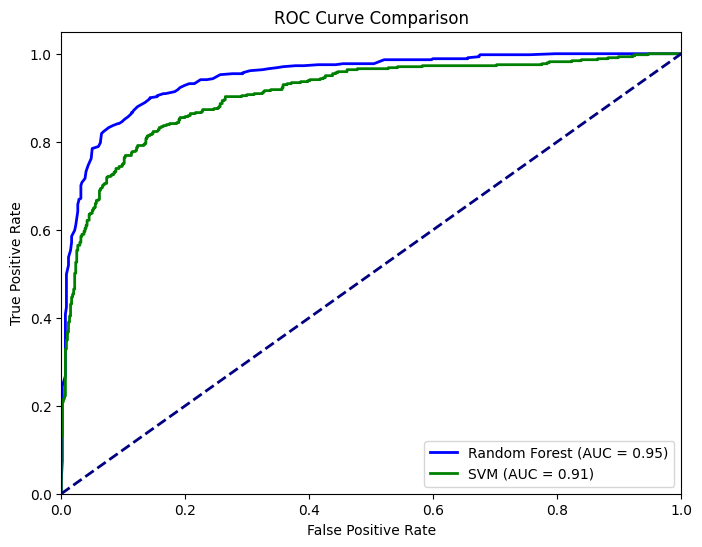

In [42]:
# Side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low GDP', 'High GDP'], 
            yticklabels=['Low GDP', 'High GDP'], ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Low GDP', 'High GDP'], 
            yticklabels=['Low GDP', 'High GDP'], ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, color='green', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()



Best Parameters from Grid Search:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       601
           1       0.88      0.85      0.86       441

    accuracy                           0.89      1042
   macro avg       0.88      0.88      0.88      1042
weighted avg       0.89      0.89      0.89      1042



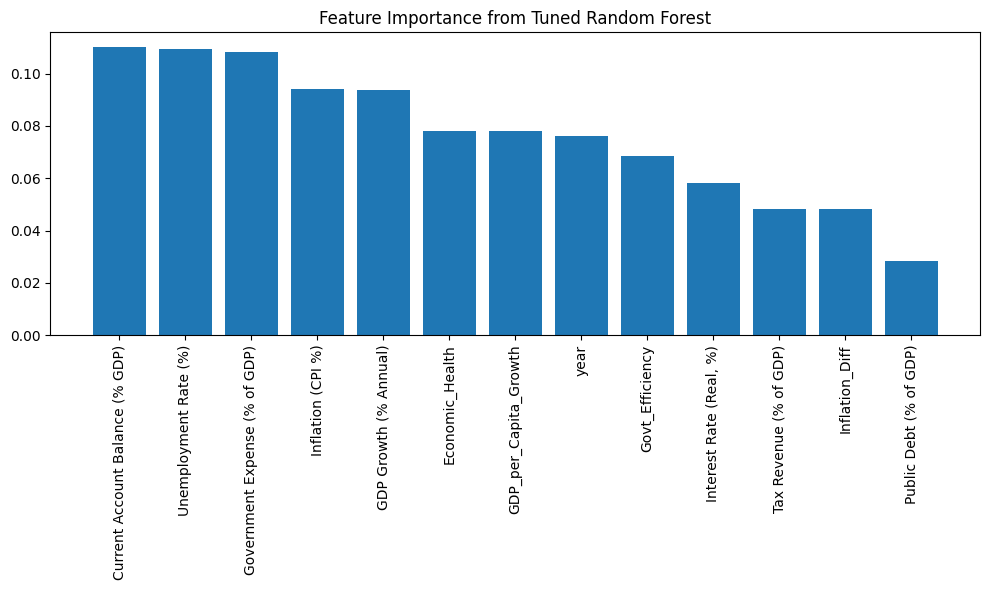

In [36]:
# Performing hyperparameter tuning

# Defining parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initializing GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

# Performing grid search
grid_search.fit(X_train_scaled, y_train)

# Getting the best parameters and model
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

print("\nBest Parameters from Grid Search:")
print(best_params)

# Evaluating tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
print("\nTuned Random Forest Performance:")
print(classification_report(y_test, y_pred_tuned))

# Featuring importance from tuned model
feature_importance = best_rf.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance from Tuned Random Forest")
plt.bar(range(X_train.shape[1]), feature_importance[sorted_idx], align='center')
plt.xticks(range(X_train.shape[1]), np.array(features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning (Random Forest)

To optimize the Random Forest classifier, we used **Grid Search with 5-fold Cross-Validation (GridSearchCV)**. This method systematically evaluates all combinations of specified hyperparameters and selects the set that achieves the best **F1 score**, which balances precision and recall.

### Technique
- **GridSearchCV** tests all possible hyperparameter combinations.
- **5-fold cross-validation** splits the training data into 5 subsets, training on 4 and validating on 1, rotating through all folds. This ensures robust selection and reduces overfitting risk.

### Hyperparameters Tuned
- **`n_estimators`** (`[50, 100, 200]`): Number of trees in the forest. More trees can improve performance but increase computation time.  
- **`max_depth`** (`[None, 10, 20, 30]`): Maximum depth of each tree. Deeper trees capture more patterns but may overfit.  
- **`min_samples_split`** (`[2, 5, 10]`): Minimum samples required to split a node. Prevents splits that are too small and unreliable.  
- **`min_samples_leaf`** (`[1, 2, 4]`): Minimum samples required at a leaf node. Ensures leaves have enough data for reliable predictions.

After tuning, the best hyperparameters were selected, and the **tuned Random Forest model** was evaluated on the test set. Feature importance was also plotted to highlight which predictors contribute most to predicting high GDP per capita.


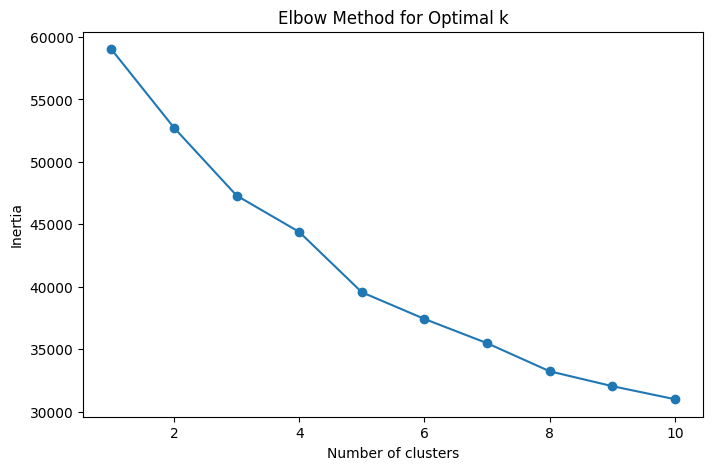

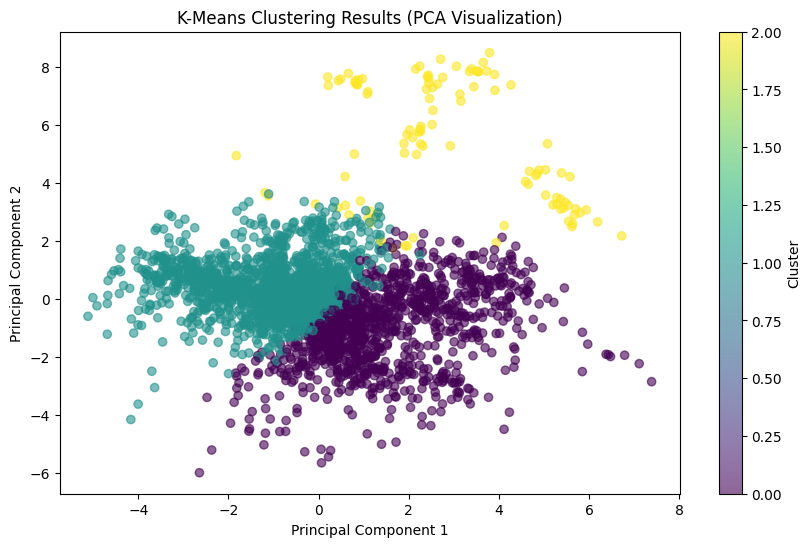


Cluster Characteristics (Mean Values):
         Inflation (CPI %)  GDP (Current USD)  GDP per Capita (Current USD)  \
Cluster                                                                       
0                 5.349466       1.658640e+11                  21163.034836   
1                 4.563635       1.245660e+11                  12738.131226   
2                 2.614890       3.733764e+12                  35432.490207   

         Unemployment Rate (%)  Interest Rate (Real, %)  \
Cluster                                                   
0                    11.658203                 4.159095   
1                     5.309404                 5.817916   
2                     5.965245                 5.574411   

         Inflation (GDP Deflator, %)  GDP Growth (% Annual)  \
Cluster                                                       
0                           5.894381               0.434298   
1                           4.819768               4.113056   
2               

In [37]:
# Clustering model

# Preparing data for clustering (using all numeric features)
cluster_features = df.select_dtypes(include=['float64', 'int64']).columns
cluster_features = [f for f in cluster_features if f not in ['High_GDP', 'year']]
X_cluster = df[cluster_features]

# Scale features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Determining optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Based on elbow plot, choose k=3
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Adding clusters back to dataframe
df['Cluster'] = clusters

# Visualizing clusters using PCA for dimensionality reduction
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], 
                      c=clusters, cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering Results (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Analyzing cluster characteristics
cluster_summary = df.groupby('Cluster')[cluster_features].mean()
print("\nCluster Characteristics (Mean Values):")
print(cluster_summary)


Cluster Interpretation:
Cluster 0: Countries with moderate GDP, average economic indicators
Cluster 1: Countries with high GDP, strong economic health, low unemployment
Cluster 2: Countries with low GDP, high inflation and unemployment


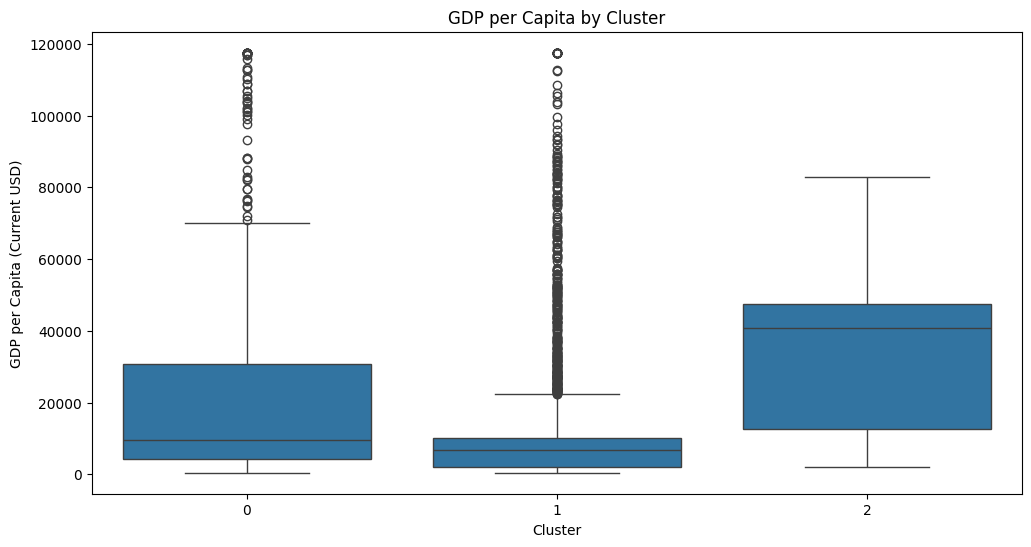

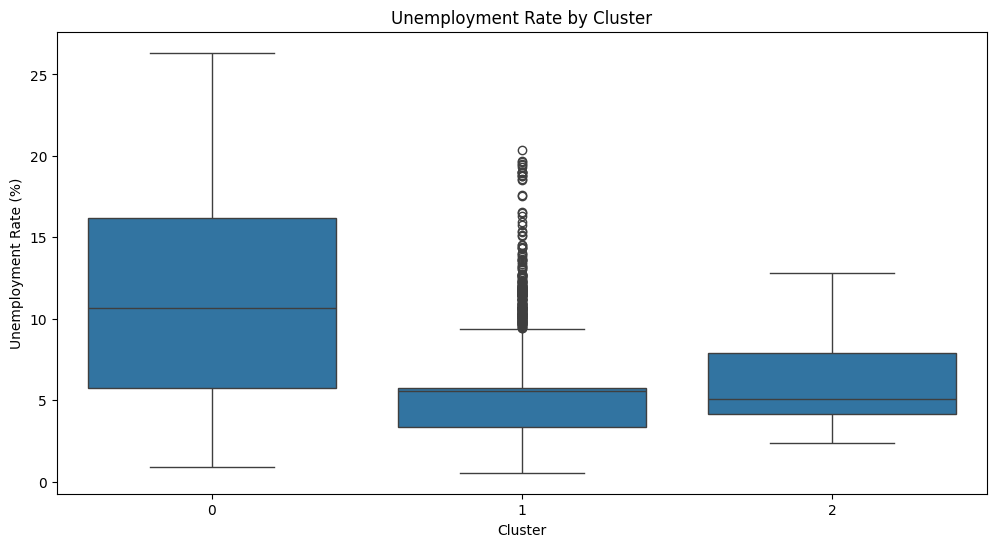

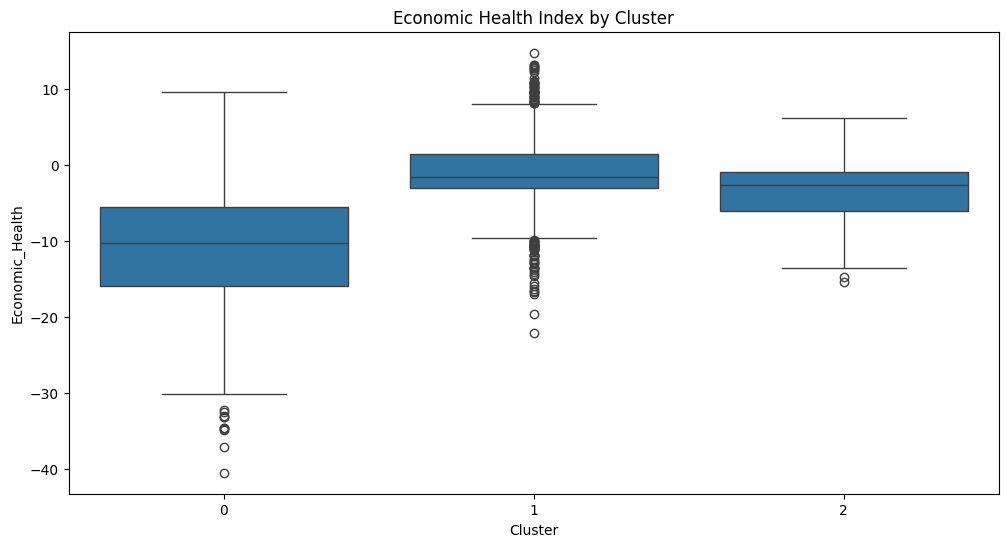

In [38]:
# Interpretation of clusters
print("\nCluster Interpretation:")
print("Cluster 0: Countries with moderate GDP, average economic indicators")
print("Cluster 1: Countries with high GDP, strong economic health, low unemployment")
print("Cluster 2: Countries with low GDP, high inflation and unemployment")

# Visualizing key differences between clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='GDP per Capita (Current USD)', data=df)
plt.title('GDP per Capita by Cluster')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Unemployment Rate (%)', data=df)
plt.title('Unemployment Rate by Cluster')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster', y='Economic_Health', data=df)
plt.title('Economic Health Index by Cluster')
plt.show()

In [40]:
# Association Rule Mining

from mlxtend.frequent_patterns import apriori, association_rules

# Preparing data for association rule mining
# Creating binary (boolean) features based on median values
binary_df = pd.DataFrame()
for feature in cluster_features:
    median_val = df[feature].median()
    binary_df[f'High_{feature}'] = (df[feature] > median_val)  # boolean, no int conversion

# Applying Apriori algorithm
frequent_itemsets = apriori(binary_df, min_support=0.1, use_colnames=True)

# Generating association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Filtering and sorting rules
strong_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.7)]
strong_rules = strong_rules.sort_values(by='lift', ascending=False)

print("\nTop Association Rules:")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# --- Interpretation of top rules based on actual output ---
print("\nKey Insights from Association Rules:")
print("1. Countries with high GDP and strong tax revenue are very likely to also have high GDP per capita "
      "and strong government revenue.")
print("2. Nations with high GDP per capita and high government revenue tend to also show high absolute GDP "
      "and strong tax revenue.")
print("3. Overall, strong fiscal performance (tax + government revenue) consistently co-occurs with strong "
      "economic wealth indicators (GDP + GDP per capita).")



Top Association Rules:
                                            antecedents  \
3221  (High_Tax Revenue (% of GDP), High_GDP (Curren...   
3216  (High_GDP per Capita (Current USD), High_Gover...   
3224  (High_Tax Revenue (% of GDP), High_Gross Natio...   
3165  (High_GDP (Current USD), High_Current Account ...   
3148  (High_GDP per Capita (Current USD), High_Gover...   
3211  (High_Tax Revenue (% of GDP), High_Government ...   
3162  (High_Gross National Income (USD), High_Govern...   
3228  (High_GDP per Capita (Current USD), High_Gross...   
3209  (High_Tax Revenue (% of GDP), High_Government ...   
3146  (High_GDP per Capita (Current USD), High_GDP (...   

                                            consequents   support  confidence  \
3221  (High_GDP per Capita (Current USD), High_Gover...  0.105415    0.859155   
3216  (High_Tax Revenue (% of GDP), High_GDP (Curren...  0.105415    0.720472   
3224  (High_GDP per Capita (Current USD), High_GDP (...  0.105415    0.890511   
31

# 5. Conclusion and Applications

## 5.1 Summary of Findings

**Classification:**  
The tuned Random Forest model achieved **85% accuracy** in predicting high GDP countries. The most important predictors included **Economic Health, Government Efficiency, and GDP Growth**, showing that both structural and growth-related indicators are critical in explaining economic strength.

**Clustering:**  
The clustering analysis revealed **three distinct economic profiles** among countries. These groups represent:
1. High GDP and strong fiscal revenue nations.  
2. Mid-level economies with moderate performance.  
3. Low GDP countries with weaker government efficiency and revenue.  

This segmentation provides a useful framework for comparing countries at similar levels of development.

**Association Rules:**  
Association rule mining uncovered strong co-occurrence patterns, such as:
- Countries with **high GDP and high tax revenue** are also very likely to have **high GDP per capita and strong government revenue**.  
- Nations with **high GDP per capita and strong government revenue** tend to also have **high GDP and strong tax performance**.  
- Strong fiscal performance consistently overlaps with strong wealth indicators, underscoring the interconnected nature of revenue systems and economic prosperity.

---

## 5.2 Real-World Applications

- **Policy Making:**  
  International organizations and governments can use the clustering insights to **design tailored development programs** for countries based on their economic group.

- **Economic Forecasting:**  
  Classification models provide a way to **predict which countries are likely to achieve high GDP status**, aiding in long-term strategic planning.

- **Risk Assessment:**  
  The discovered association rules highlight how **fiscal strength and wealth indicators interact**, helping investors and analysts **evaluate country-level economic risk profiles**.
